In [167]:
# Install required libraries

!pip install requests beautifulsoup4 pandas numpy matplotlib seaborn plotly scipy scikit-learn missingno

# Project Title

# CoinGecko API + Web Scraping → Data Cleaning → Exploratory Data Analysis

In [168]:
# Data handling
import pandas as pd
import numpy as np

# API and web scraping
import requests
from bs4 import BeautifulSoup

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistical analysis
from scipy import stats

# Machine learning - outlier detection
from sklearn.ensemble import IsolationForest

# Missing-value visualization
import missingno as msno

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set a simple visualization style
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [169]:
# Import required libraries

import requests
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [170]:
# CoinGecko API endpoint
url = "https://api.coingecko.com/api/v3/coins/markets"

# Parameters used to request cryptocurrency market data
params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": "false",
    "price_change_percentage": "24h"
}

print("API URL and parameters are ready!")

API URL and parameters are ready!


In [171]:
# Send request to CoinGecko API

response = requests.get(
    url,
    params=params,
    timeout=30
)

# Display status code
print("Status Code:", response.status_code)

# Check connection
if response.status_code == 200:
    print("CoinGecko API connected successfully!")
else:
    print("API connection failed.")
    print(response.text[:500])

Status Code: 200
CoinGecko API connected successfully!


# Get API data

In [172]:
# Convert API response into Python data

crypto_data = response.json()

# Check the number of records
print("Number of cryptocurrency records:", len(crypto_data))

Number of cryptocurrency records: 100


In [173]:
# Convert the API data into a pandas DataFrame

crypto_df = pd.DataFrame(crypto_data)

# Display first 5 rows
crypto_df.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated,price_change_percentage_24h_in_currency
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,77907.000000,1564457575007,1,1564459522572,3.230801e+10,79607.000000,...,2.100000e+07,126080.00,-38.20830,2025-10-06T10:57:42.000Z,67.810000,1.147917e+05,2013-07-05T16:00:00.000Z,None,2026-09-10T10:36:20.000Z,-1.51563
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2466.230000,300961298087,2,300961298087,1.239376e+10,2517.550000,...,NaN,4946.05,-50.13724,2025-08-24T11:21:03.000Z,0.432979,5.694974e+05,2015-10-19T16:00:00.000Z,"{'times': 41.322079079185485, 'currency': 'btc...",2026-09-10T10:36:20.000Z,-1.01812
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999694,183403829454,3,188869076382,5.391060e+10,0.999919,...,NaN,1.32,-24.44275,2018-07-23T16:00:00.000Z,0.572521,7.461271e+01,2015-03-01T16:00:00.000Z,None,2026-09-10T10:36:20.000Z,-0.02008
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,717.130000,95498439928,4,95498438651,1.145687e+09,751.220000,...,2.000000e+08,1369.99,-47.65435,2025-10-13T00:41:24.000Z,0.039818,1.800936e+06,2017-10-18T16:00:00.000Z,None,2026-09-10T10:36:20.000Z,-4.42487
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.370000,86254943532,5,137450358255,2.247450e+09,1.440000,...,1.000000e+11,3.65,-62.29496,2025-07-17T19:40:53.000Z,0.002686,5.108252e+04,2014-05-21T16:00:00.000Z,None,2026-09-10T10:36:20.000Z,-3.42901


In [174]:
# Display all columns available in the dataset

print("Columns in Crypto Dataset:")

print(crypto_df.columns.tolist())

Columns in Crypto Dataset:
['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi', 'last_updated', 'price_change_percentage_24h_in_currency']


In [175]:
# Select only the columns needed for our project

crypto_columns = [
    "id",
    "symbol",
    "name",
    "current_price",
    "market_cap",
    "market_cap_rank",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_percentage_24h",
    "circulating_supply",
    "total_supply",
    "max_supply",
    "last_updated"
]

crypto_df = crypto_df[crypto_columns]

print("Required columns selected successfully!")

Required columns selected successfully!


In [176]:
# Display first 10 cryptocurrency records

crypto_df.head(10)

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_percentage_24h,circulating_supply,total_supply,max_supply,last_updated
0,bitcoin,btc,Bitcoin,77907.000000,1564457575007,1,3.230801e+10,79607.000000,77833.000000,-1.51563,2.008222e+07,2.008228e+07,2.100000e+07,2026-09-10T10:36:20.000Z
1,ethereum,eth,Ethereum,2466.230000,300961298087,2,1.239376e+10,2517.550000,2445.100000,-1.01812,1.220356e+08,1.220356e+08,NaN,2026-09-10T10:36:20.000Z
2,tether,usdt,Tether,0.999694,183403829454,3,5.391060e+10,0.999919,0.999558,-0.02008,1.834608e+11,1.889278e+11,NaN,2026-09-10T10:36:20.000Z
3,binancecoin,bnb,BNB,717.130000,95498439928,4,1.145687e+09,751.220000,715.600000,-4.42487,1.331612e+08,1.331612e+08,2.000000e+08,2026-09-10T10:36:20.000Z
4,ripple,xrp,XRP,1.370000,86254943532,5,2.247450e+09,1.440000,1.380000,-3.42901,6.274450e+10,9.998563e+10,1.000000e+11,2026-09-10T10:36:20.000Z
5,usd-coin,usdc,USDC,0.999853,74305018957,6,1.596621e+10,1.000000,0.999718,-0.00934,7.431656e+10,7.431842e+10,NaN,2026-09-10T10:36:20.000Z
6,solana,sol,Solana,101.020000,59225839950,7,3.223519e+09,104.770000,100.570000,-2.83956,5.863357e+08,6.338310e+08,NaN,2026-09-10T10:36:20.000Z
7,tron,trx,TRON,0.340358,32314798619,8,3.460063e+08,0.340659,0.338005,0.44700,9.494200e+10,9.494342e+10,NaN,2026-09-10T10:36:20.000Z
8,figure-heloc,figr_heloc,Figure Heloc,1.027000,22973494257,9,1.140566e+08,1.042000,1.019000,NaN,2.237903e+10,2.237903e+10,NaN,2026-09-10T10:36:20.000Z
9,zcash,zec,Zcash,1221.050000,20657038898,10,1.444607e+09,1293.920000,1206.720000,-1.83448,1.692187e+07,1.692466e+07,2.100000e+07,2026-09-10T10:36:20.000Z


In [177]:
# Display number of rows and columns

print("Rows:", crypto_df.shape[0])
print("Columns:", crypto_df.shape[1])

Rows: 100
Columns: 14


In [178]:
# Display dataset information

crypto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           100 non-null    object 
 1   symbol                       100 non-null    object 
 2   name                         100 non-null    object 
 3   current_price                100 non-null    float64
 4   market_cap                   100 non-null    int64  
 5   market_cap_rank              100 non-null    int64  
 6   total_volume                 100 non-null    float64
 7   high_24h                     100 non-null    float64
 8   low_24h                      100 non-null    float64
 9   price_change_percentage_24h  99 non-null     float64
 10  circulating_supply           100 non-null    float64
 11  total_supply                 100 non-null    float64
 12  max_supply                   51 non-null     float64
 13  last_updated         

In [179]:
# Generate statistical summary for numerical columns

crypto_df.describe()

,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_percentage_24h,circulating_supply,total_supply,max_supply
count,100.000000,1.000000e+02,100.000000,1.000000e+02,100.000000,100.000000,99.000000,1.000000e+02,1.000000e+02,5.100000e+01
mean,930.134399,2.685704e+10,50.500000,1.407832e+09,950.572448,928.786925,-2.571545,1.910543e+13,1.912033e+13,2.791563e+13
std,7804.369015,1.598209e+11,29.011492,6.520877e+09,7974.213697,7796.935383,3.634198,1.143495e+14,1.143604e+14,1.508124e+14
min,0.000002,5.477599e+08,1.000000,0.000000e+00,0.000002,0.000002,-11.708570,4.325033e+05,4.325033e+05,1.461249e+07
25%,0.223150,9.736389e+08,25.750000,9.791029e+06,0.245701,0.222398,-4.874410,4.038759e+08,5.326248e+08,4.000000e+08
50%,0.999955,1.748314e+09,50.500000,7.496162e+07,1.000000,0.999802,-1.515630,1.603034e+09,1.819109e+09,6.219317e+09
75%,7.115000,4.014411e+09,75.250000,2.304969e+08,7.297500,7.107500,-0.000085,1.024943e+10,1.178383e+10,2.608335e+10
max,77907.000000,1.564458e+12,100.000000,5.391060e+10,79607.000000,77833.000000,7.765260,8.982327e+14,8.982327e+14,9.999900e+14


In [180]:
# Count missing values in every column

missing_values = crypto_df.isnull().sum()

print(missing_values)

id                              0
symbol                          0
name                            0
current_price                   0
market_cap                      0
market_cap_rank                 0
total_volume                    0
high_24h                        0
low_24h                         0
price_change_percentage_24h     1
circulating_supply              0
total_supply                    0
max_supply                     49
last_updated                    0
dtype: int64


In [181]:
# Calculate percentage of missing values

missing_percentage = (
    crypto_df.isnull().mean() * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing Count": crypto_df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Count,Missing Percentage
id,0,0.0
symbol,0,0.0
name,0,0.0
current_price,0,0.0
market_cap,0,0.0
market_cap_rank,0,0.0
total_volume,0,0.0
high_24h,0,0.0
low_24h,0,0.0
price_change_percentage_24h,1,1.0


In [182]:
# Check complete duplicate rows

duplicate_rows = crypto_df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [183]:
# Check duplicate cryptocurrency IDs

duplicate_ids = crypto_df["id"].duplicated().sum()

print("Duplicate cryptocurrency IDs:", duplicate_ids)

Duplicate cryptocurrency IDs: 0


In [184]:
# Remove duplicate cryptocurrencies using ID

crypto_df = crypto_df.drop_duplicates(
    subset="id"
)

print("Duplicates removed successfully!")
print("New shape:", crypto_df.shape)

Duplicates removed successfully!
New shape: (100, 14)


In [264]:
# Save CoinGecko API data as raw dataset
crypto_df.to_csv("crypto_raw.csv", index=False)

print("Raw dataset saved successfully.")
print("Shape:", crypto_df.shape)
crypto_df.head()

Raw dataset saved successfully.
Shape: (100, 18)


,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_percentage_24h,circulating_supply,total_supply,max_supply,last_updated,Market Cap Category,Volatility Score,Supply Ratio,Anomaly
0,bitcoin,btc,Bitcoin,77907.000000,1564457575007,1,3.230801e+10,79607.000000,77833.000000,-1.51563,2.008222e+07,2.008228e+07,2.100000e+07,2026-09-10 10:36:20+00:00,Large Cap,1.51563,0.956296,-1
1,ethereum,eth,Ethereum,2466.230000,300961298087,2,1.239376e+10,2517.550000,2445.100000,-1.01812,1.220356e+08,1.220356e+08,NaN,2026-09-10 10:36:20+00:00,Large Cap,1.01812,NaN,-1
2,tether,usdt,Tether,0.999694,183403829454,3,5.391060e+10,0.999919,0.999558,-0.02008,1.834608e+11,1.889278e+11,NaN,2026-09-10 10:36:20+00:00,Large Cap,0.02008,NaN,-1
3,binancecoin,bnb,BNB,717.130000,95498439928,4,1.145687e+09,751.220000,715.600000,-4.42487,1.331612e+08,1.331612e+08,2.000000e+08,2026-09-10 10:36:20+00:00,Large Cap,4.42487,0.665806,-1
4,ripple,xrp,XRP,1.370000,86254943532,5,2.247450e+09,1.440000,1.380000,-3.42901,6.274450e+10,9.998563e+10,1.000000e+11,2026-09-10 10:36:20+00:00,Large Cap,3.42901,0.627445,1


# Data Cleaning

In [185]:
# List of columns that should contain numerical values

numeric_columns = [
    "current_price",
    "market_cap",
    "market_cap_rank",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_percentage_24h",
    "circulating_supply",
    "total_supply",
    "max_supply"
]

# Convert each column to numeric
# Invalid values will become NaN

for column in numeric_columns:
    crypto_df[column] = pd.to_numeric(
        crypto_df[column],
        errors="coerce"
    )

print("Numerical columns converted successfully!")

Numerical columns converted successfully!


In [186]:
# Convert last_updated column to datetime

crypto_df["last_updated"] = pd.to_datetime(
    crypto_df["last_updated"],
    errors="coerce"
)

print("Date column converted successfully!")

Date column converted successfully!


In [187]:
# Check data types after conversion

crypto_df.dtypes

id                                          object
symbol                                      object
name                                        object
current_price                              float64
market_cap                                   int64
market_cap_rank                              int64
total_volume                               float64
high_24h                                   float64
low_24h                                    float64
price_change_percentage_24h                float64
circulating_supply                         float64
total_supply                               float64
max_supply                                 float64
last_updated                   datetime64[ns, UTC]
dtype: object

In [188]:
# Check missing current prices

print(
    "Missing prices:",
    crypto_df["current_price"].isnull().sum()
)

Missing prices: 0


In [189]:
# Remove records where current price is missing

crypto_df = crypto_df.dropna(
    subset=["current_price"]
)

print("Missing price records handled!")

Missing price records handled!


In [190]:
# Columns where median filling is reasonable

fill_columns = [
    "market_cap",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_percentage_24h",
    "circulating_supply"
]

# Fill missing values with column median

for column in fill_columns:

    crypto_df[column] = crypto_df[column].fillna(
        crypto_df[column].median()
    )

print("Missing numerical values handled!")

Missing numerical values handled!


In [191]:
# Check missing values after cleaning

crypto_df.isnull().sum()

id                              0
symbol                          0
name                            0
current_price                   0
market_cap                      0
market_cap_rank                 0
total_volume                    0
high_24h                        0
low_24h                         0
price_change_percentage_24h     0
circulating_supply              0
total_supply                    0
max_supply                     49
last_updated                    0
dtype: int64

In [192]:
# Keep only positive cryptocurrency prices

crypto_df = crypto_df[
    crypto_df["current_price"] > 0
]

print("Invalid price records removed!")

Invalid price records removed!


In [193]:
# Check for negative values in important columns

important_columns = [
    "current_price",
    "market_cap",
    "total_volume"
]

for column in important_columns:

    negative_count = (
        crypto_df[column] < 0
    ).sum()

    print(
        column,
        "negative values:",
        negative_count
    )

current_price negative values: 0
market_cap negative values: 0
total_volume negative values: 0


In [194]:
# Keep records with valid non-negative market values

crypto_df = crypto_df[
    (crypto_df["market_cap"] >= 0) &
    (crypto_df["total_volume"] >= 0)
]

print("Invalid market values removed!")

Invalid market values removed!


# Feature Engineering

In [195]:
# Create a category based on market capitalization

def market_cap_category(value):

    if value >= 10_000_000_000:
        return "Large Cap"

    elif value >= 1_000_000_000:
        return "Mid Cap"

    else:
        return "Small Cap"


crypto_df["Market Cap Category"] = (
    crypto_df["market_cap"]
    .apply(market_cap_category)
)

crypto_df[
    ["name", "market_cap", "Market Cap Category"]
].head()

,name,market_cap,Market Cap Category
0,Bitcoin,1564457575007,Large Cap
1,Ethereum,300961298087,Large Cap
2,Tether,183403829454,Large Cap
3,BNB,95498439928,Large Cap
4,XRP,86254943532,Large Cap


In [196]:
# Calculate a simple volatility score

crypto_df["Volatility Score"] = (
    crypto_df["price_change_percentage_24h"]
    .abs()
)

crypto_df[
    [
        "name",
        "price_change_percentage_24h",
        "Volatility Score"
    ]
].head()

,name,price_change_percentage_24h,Volatility Score
0,Bitcoin,-1.51563,1.51563
1,Ethereum,-1.01812,1.01812
2,Tether,-0.02008,0.02008
3,BNB,-4.42487,4.42487
4,XRP,-3.42901,3.42901


In [197]:
# Calculate the percentage of maximum supply currently circulating

crypto_df["Supply Ratio"] = np.where(
    crypto_df["max_supply"] > 0,
    crypto_df["circulating_supply"] /
    crypto_df["max_supply"],
    np.nan
)

crypto_df[
    [
        "name",
        "circulating_supply",
        "max_supply",
        "Supply Ratio"
    ]
].head()

,name,circulating_supply,max_supply,Supply Ratio
0,Bitcoin,2.008222e+07,2.100000e+07,0.956296
1,Ethereum,1.220356e+08,NaN,NaN
2,Tether,1.834608e+11,NaN,NaN
3,BNB,1.331612e+08,2.000000e+08,0.665806
4,XRP,6.274450e+10,1.000000e+11,0.627445


In [198]:
# Function to detect outliers using the IQR method

def find_iqr_outliers(df, column):

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    return outliers

In [199]:
# Detect market capitalization outliers

market_cap_outliers = find_iqr_outliers(
    crypto_df,
    "market_cap"
)

print(
    "Market cap outliers:",
    len(market_cap_outliers)
)

Market cap outliers: 17


In [200]:
# Detect cryptocurrency price outliers

price_outliers = find_iqr_outliers(
    crypto_df,
    "current_price"
)

print(
    "Price outliers:",
    len(price_outliers)
)

Price outliers: 19


In [201]:
# Detect trading volume outliers

volume_outliers = find_iqr_outliers(
    crypto_df,
    "total_volume"
)

print(
    "Volume outliers:",
    len(volume_outliers)
)

Volume outliers: 15


In [202]:
# Import Isolation Forest

from sklearn.ensemble import IsolationForest

# Features used for anomaly detection

outlier_features = [
    "current_price",
    "market_cap",
    "total_volume"
]

# Create temporary dataset

temp_data = crypto_df[
    outlier_features
].copy()

# Fill missing values for the model

temp_data = temp_data.fillna(
    temp_data.median()
)

# Create Isolation Forest model

isolation_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Train the model

isolation_model.fit(temp_data)

# Predict anomalies

crypto_df["Anomaly"] = isolation_model.predict(
    temp_data
)

print(
    crypto_df["Anomaly"].value_counts()
)

Anomaly
 1    95
-1     5
Name: count, dtype: int64


# Crypto EDA

In [203]:
# Display cleaned dataset

crypto_df.head()

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_percentage_24h,circulating_supply,total_supply,max_supply,last_updated,Market Cap Category,Volatility Score,Supply Ratio,Anomaly
0,bitcoin,btc,Bitcoin,77907.000000,1564457575007,1,3.230801e+10,79607.000000,77833.000000,-1.51563,2.008222e+07,2.008228e+07,2.100000e+07,2026-09-10 10:36:20+00:00,Large Cap,1.51563,0.956296,-1
1,ethereum,eth,Ethereum,2466.230000,300961298087,2,1.239376e+10,2517.550000,2445.100000,-1.01812,1.220356e+08,1.220356e+08,NaN,2026-09-10 10:36:20+00:00,Large Cap,1.01812,NaN,-1
2,tether,usdt,Tether,0.999694,183403829454,3,5.391060e+10,0.999919,0.999558,-0.02008,1.834608e+11,1.889278e+11,NaN,2026-09-10 10:36:20+00:00,Large Cap,0.02008,NaN,-1
3,binancecoin,bnb,BNB,717.130000,95498439928,4,1.145687e+09,751.220000,715.600000,-4.42487,1.331612e+08,1.331612e+08,2.000000e+08,2026-09-10 10:36:20+00:00,Large Cap,4.42487,0.665806,-1
4,ripple,xrp,XRP,1.370000,86254943532,5,2.247450e+09,1.440000,1.380000,-3.42901,6.274450e+10,9.998563e+10,1.000000e+11,2026-09-10 10:36:20+00:00,Large Cap,3.42901,0.627445,1


In [204]:
print("Final Crypto Dataset Shape:")
print(crypto_df.shape)

Final Crypto Dataset Shape:
(100, 18)


In [205]:
print("Final Missing Values:")
print(crypto_df.isnull().sum())

Final Missing Values:
id                              0
symbol                          0
name                            0
current_price                   0
market_cap                      0
market_cap_rank                 0
total_volume                    0
high_24h                        0
low_24h                         0
price_change_percentage_24h     0
circulating_supply              0
total_supply                    0
max_supply                     49
last_updated                    0
Market Cap Category             0
Volatility Score                0
Supply Ratio                   49
Anomaly                         0
dtype: int64


In [206]:
print(
    "Duplicate rows:",
    crypto_df.duplicated().sum()
)

print(
    "Duplicate IDs:",
    crypto_df["id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate IDs: 0


In [207]:
# Save the cleaned CoinGecko dataset

crypto_df.to_csv(
    "coingecko_crypto_cleaned.csv",
    index=False
)

print(
    "coingecko_crypto_cleaned.csv saved successfully!"
)

coingecko_crypto_cleaned.csv saved successfully!


# EDA Visualizations

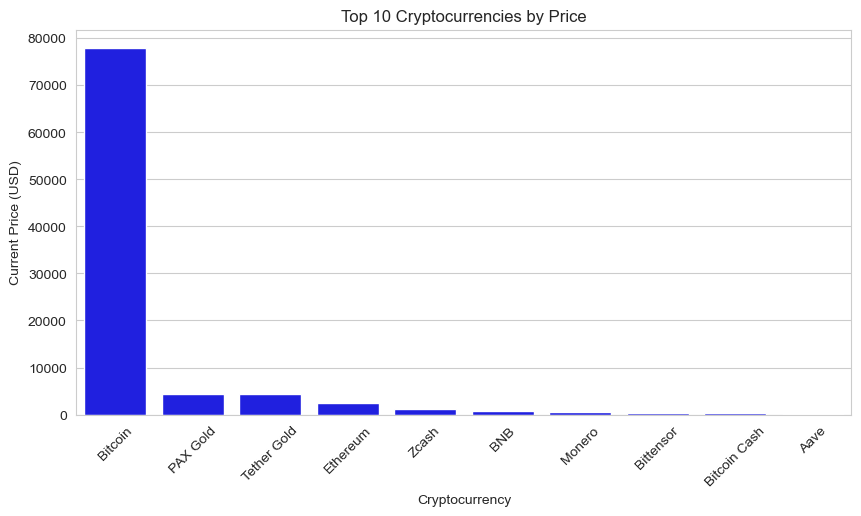

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

top_price = crypto_df.nlargest(10, "current_price")

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_price,
    x="name",
    y="current_price",
    color="blue"
)

plt.title("Top 10 Cryptocurrencies by Price")
plt.xlabel("Cryptocurrency")
plt.ylabel("Current Price (USD)")

plt.xticks(rotation=45)
plt.show()

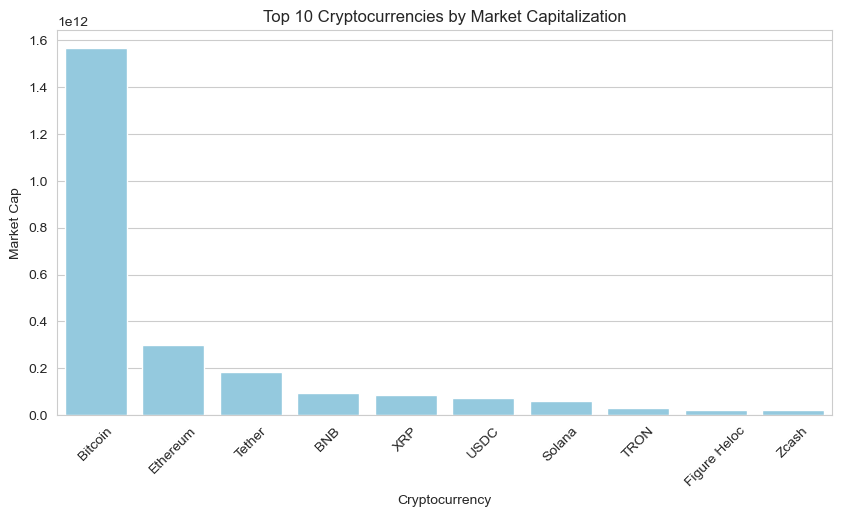

In [209]:
top_crypto = crypto_df.nlargest(10, "market_cap")

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_crypto,
    x="name",
    y="market_cap",
    color="skyblue"
)

plt.title("Top 10 Cryptocurrencies by Market Capitalization")
plt.xlabel("Cryptocurrency")
plt.ylabel("Market Cap")

plt.xticks(rotation=45)
plt.show()

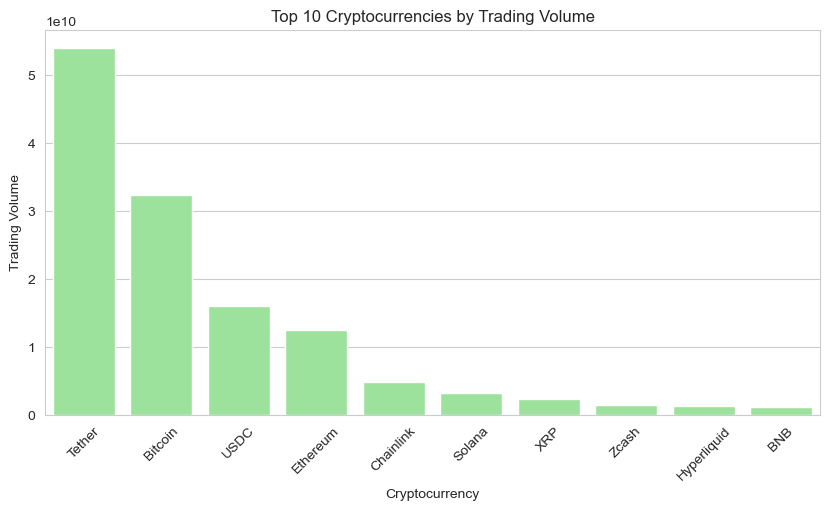

In [210]:
top_volume = crypto_df.nlargest(10, "total_volume")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_volume,
    x="name",
    y="total_volume",
    color="lightgreen"
)

plt.title("Top 10 Cryptocurrencies by Trading Volume")
plt.xlabel("Cryptocurrency")
plt.ylabel("Trading Volume")

plt.xticks(rotation=45)
plt.show()

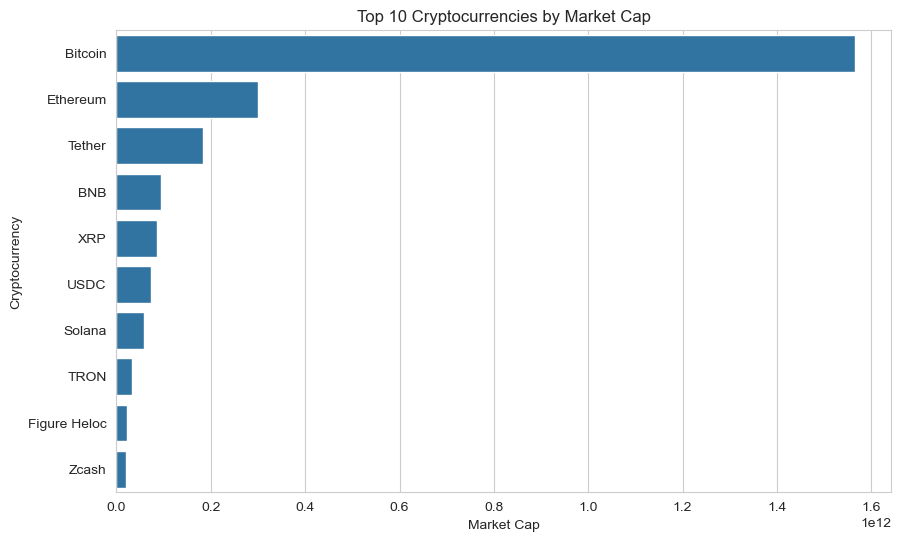

In [211]:
top_10 = crypto_df.nlargest(
    10,
    "market_cap"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x="market_cap",
    y="name"
)

plt.title("Top 10 Cryptocurrencies by Market Cap")
plt.xlabel("Market Cap")
plt.ylabel("Cryptocurrency")

plt.show()

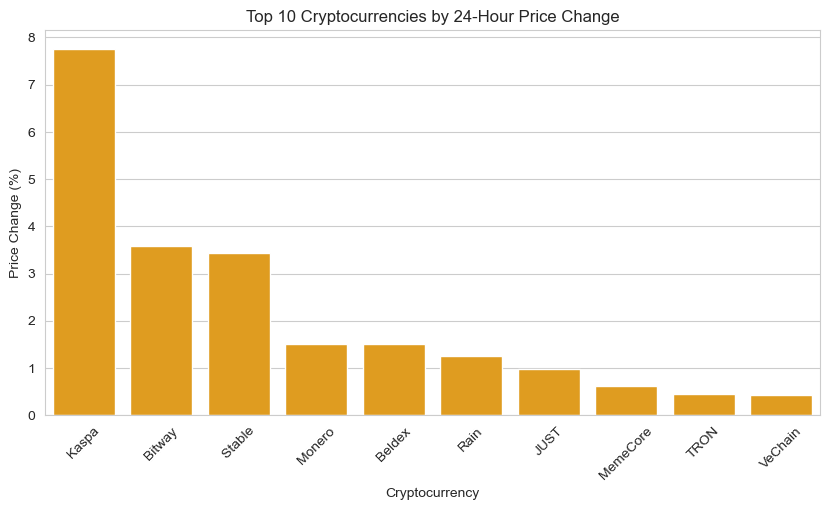

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

top_change = crypto_df.nlargest(10, "price_change_percentage_24h")

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_change,
    x="name",
    y="price_change_percentage_24h",
    color="orange"
)

plt.title("Top 10 Cryptocurrencies by 24-Hour Price Change")
plt.xlabel("Cryptocurrency")
plt.ylabel("Price Change (%)")

plt.xticks(rotation=45)
plt.show()

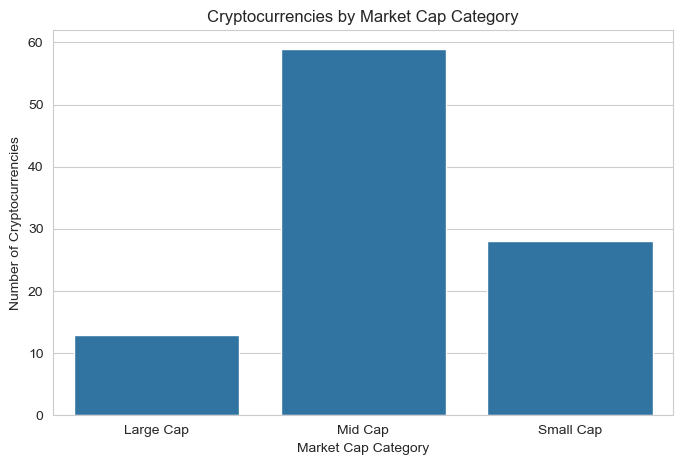

In [213]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=crypto_df,
    x="Market Cap Category"
)

plt.title("Cryptocurrencies by Market Cap Category")
plt.xlabel("Market Cap Category")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

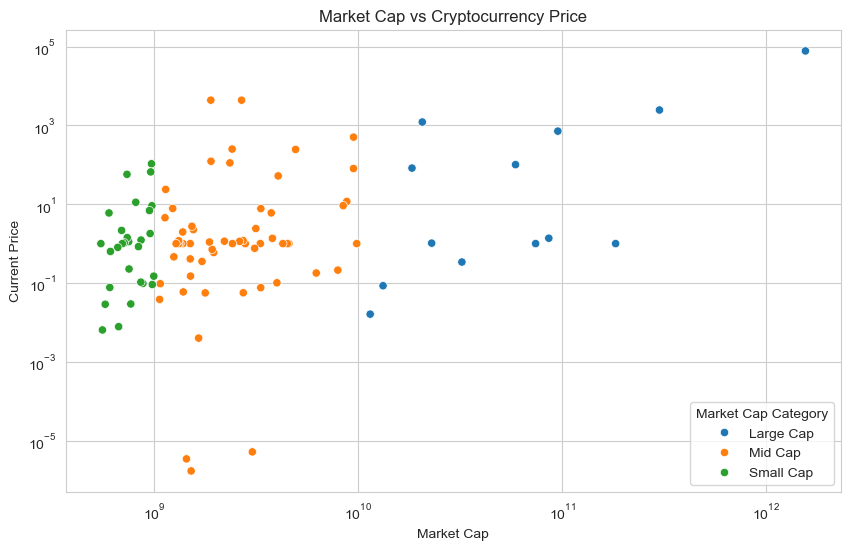

In [214]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=crypto_df,
    x="market_cap",
    y="current_price",
    hue="Market Cap Category"
)

plt.xscale("log")
plt.yscale("log")

plt.title("Market Cap vs Cryptocurrency Price")
plt.xlabel("Market Cap")
plt.ylabel("Current Price")

plt.show()

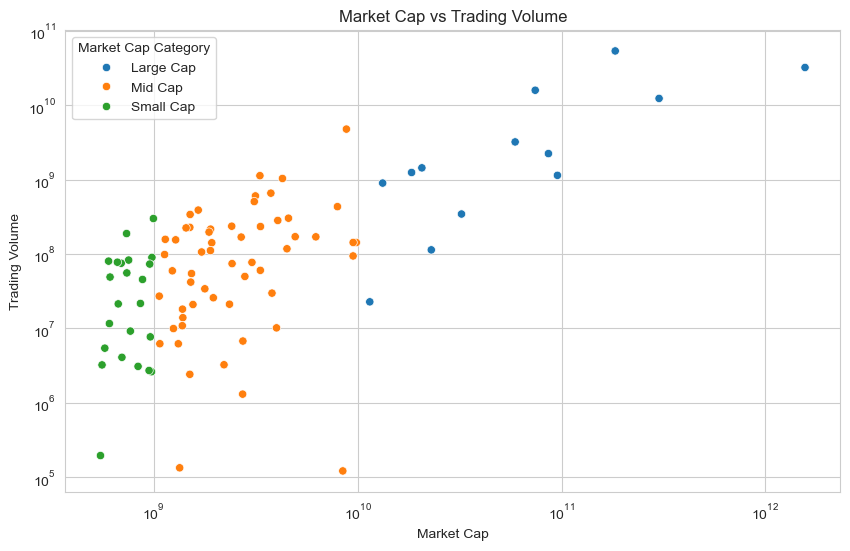

In [215]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=crypto_df,
    x="market_cap",
    y="total_volume",
    hue="Market Cap Category"
)

plt.xscale("log")
plt.yscale("log")

plt.title("Market Cap vs Trading Volume")
plt.xlabel("Market Cap")
plt.ylabel("Trading Volume")

plt.show()

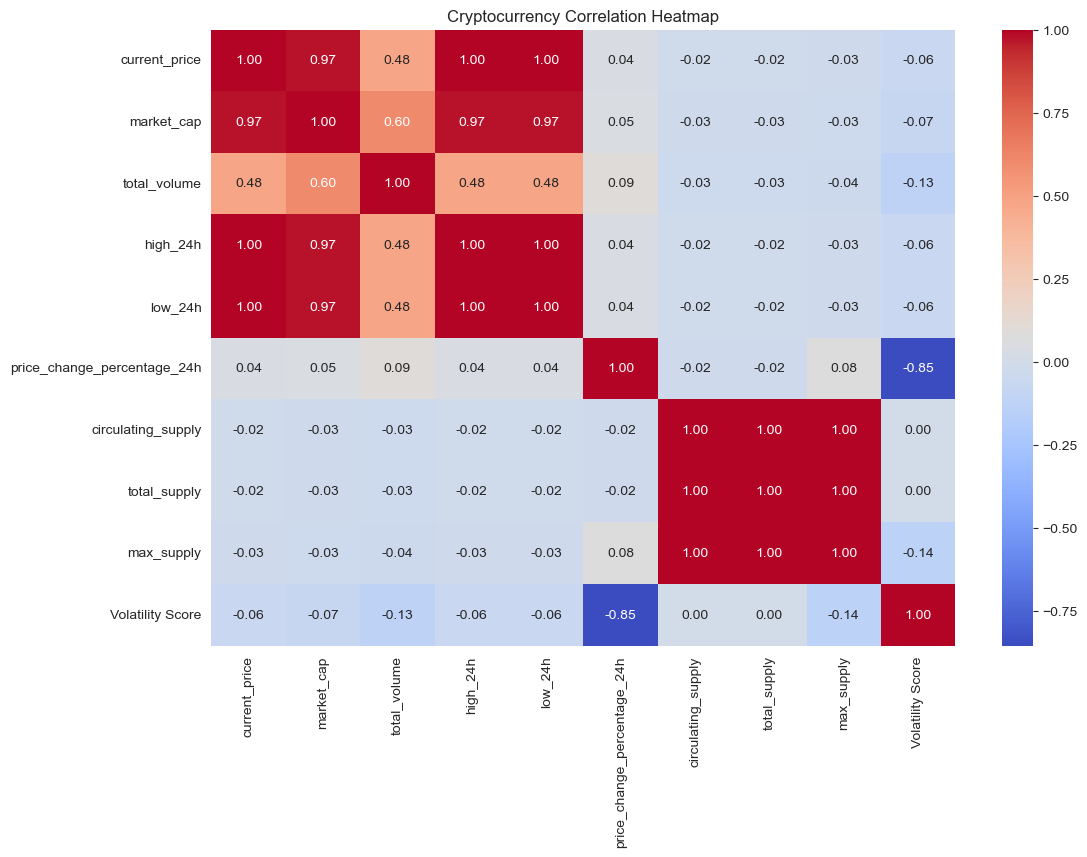

In [216]:
# Select numerical columns

correlation_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_percentage_24h",
    "circulating_supply",
    "total_supply",
    "max_supply",
    "Volatility Score"
]

# Calculate correlation

correlation = crypto_df[
    correlation_columns
].corr()

# Draw heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Cryptocurrency Correlation Heatmap")

plt.show()

In [217]:
# Find the 10 most volatile cryptocurrencies

top_volatile = crypto_df.nlargest(
    10,
    "Volatility Score"
)

top_volatile[
    [
        "name",
        "price_change_percentage_24h",
        "Volatility Score"
    ]
]

,name,price_change_percentage_24h,Volatility Score
69,Lighter,-11.70857,11.70857
88,Dash,-11.68409,11.68409
51,Pump.fun,-11.09763,11.09763
72,Arbitrum,-10.53055,10.53055
27,Uniswap,-9.43793,9.43793
55,Ethena,-9.21986,9.21986
85,Jupiter,-8.70760,8.70760
56,Worldcoin,-8.47974,8.47974
77,Cosmos Hub,-8.27150,8.27150
59,Sky,-7.95998,7.95998


In [218]:
# Compare cryptocurrencies by market cap category

crypto_summary = crypto_df.groupby(
    "Market Cap Category"
).agg(
    Average_Price=("current_price", "mean"),
    Average_Market_Cap=("market_cap", "mean"),
    Average_Volume=("total_volume", "mean"),
    Average_Volatility=("Volatility Score", "mean")
).reset_index()

crypto_summary

,Market Cap Category,Average_Price,Average_Market_Cap,Average_Volume,Average_Volatility
0,Large Cap,6346.148321,1.910133e+11,9.636637e+09,2.181231
1,Mid Cap,173.498215,3.064658e+09,2.422453e+08,3.312867
2,Small Cap,9.897038,7.755509e+08,4.337222e+07,2.802243


In [219]:
# Interactive cryptocurrency market visualization

fig = px.scatter(
    crypto_df,
    x="market_cap",
    y="total_volume",
    size="current_price",
    color="Market Cap Category",
    hover_name="name",
    log_x=True,
    log_y=True,
    title="Cryptocurrency Market Cap vs Trading Volume"
)

fig.show()

In [220]:
# Cryptocurrency with highest market cap

highest_market_cap = crypto_df.loc[
    crypto_df["market_cap"].idxmax()
]

# Cryptocurrency with highest volatility

highest_volatility = crypto_df.loc[
    crypto_df["Volatility Score"].idxmax()
]

# Cryptocurrency with highest trading volume

highest_volume = crypto_df.loc[
    crypto_df["total_volume"].idxmax()
]

print("Highest Market Cap:")
print(
    highest_market_cap["name"],
    "-",
    highest_market_cap["market_cap"]
)

print("\nHighest Volatility:")
print(
    highest_volatility["name"],
    "-",
    highest_volatility["Volatility Score"]
)

print("\nHighest Trading Volume:")
print(
    highest_volume["name"],
    "-",
    highest_volume["total_volume"]
)

Highest Market Cap:
Bitcoin - 1564457575007

Highest Volatility:
Lighter - 11.70857

Highest Trading Volume:
Tether - 53910603998.0


# 1. Cryptocurrency Data Analysis – Insights
Cryptocurrency prices vary greatly from one coin to another.

A few cryptocurrencies have much higher market capitalization than the others.

Cryptocurrencies with high market capitalization generally have higher trading volumes.

24-hour price changes show that cryptocurrency prices can change quickly.

Trading volume helps identify cryptocurrencies that are more actively traded.

The analysis shows that the cryptocurrency market has significant differences in price, market cap, and trading activity.

Missing and invalid values were handled during data cleaning to make the analysis more reliable.

Feature engineering helped categorize cryptocurrencies based on their market characteristics.
